#**Malikshah Mahimi | 221A013 | 25**

### ***RL- Exp:1 (Simple grid-world environment)***

### **1. Import Libraries**

In [1]:
print("Malikshah Mahimi | 221A013")
import os
import gymnasium as gym
import numpy as np

Malikshah Mahimi | 221A013


### **2. Load Environment**

In [2]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

In [3]:
state_ = env.reset()

In [4]:
state_
print("Malikshah Mahimi | 221A013")

Malikshah Mahimi | 221A013


In [5]:
env.observation_space.n

np.int64(500)

In [6]:
print("Malikshah Mahimi | 221A013")
env.action_space.n

Malikshah Mahimi | 221A013


np.int64(6)

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
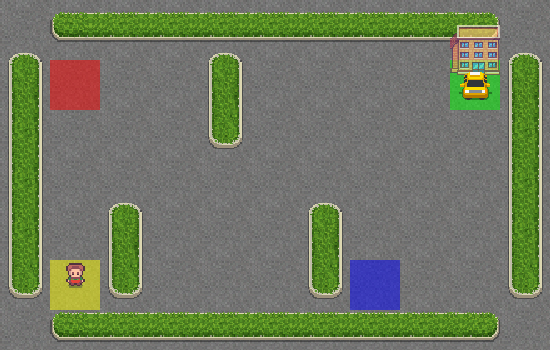

In [7]:
env.render()

### **3. Possible actions**

**down(0), up(1), right(2), left(3), pick-up(4) and drop-off(5)**

In [8]:
print("Malikshah Mahimi | 221A013")
n_states = env.observation_space.n
n_actions = env.action_space.n

Malikshah Mahimi | 221A013


In [9]:
n_actions

np.int64(6)

In [10]:
print("Malikshah Mahimi | 221A013")
n_states

Malikshah Mahimi | 221A013


np.int64(500)

In [11]:
print("Malikshah Mahimi | 221A013")
env.step(1)

Malikshah Mahimi | 221A013


(89,
 -1,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 0, 0, 1, 0, 0], dtype=int8)})

In [12]:
env.step(0)

(189,
 -1,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)})

### **4. How good does behaving completely random do ?**

In [13]:
print("Malikshah Mahimi | 221A013")
state, _ = env.reset()
counter = 0
g = 0
reward = None
while reward != 20:
    state, reward, done, truncated, info = env.step(env.action_space.sample())
    counter += 1
    g += reward
print("Solved in {} Steps with a total reward of {}".format(counter,g))

Malikshah Mahimi | 221A013
Solved in 5709 Steps with a total reward of -22104


## **Let's look at just one episode and see how the Q values change after each step using the formula below**
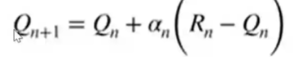

In [14]:
Q = np.zeros([n_states, n_actions])

In [21]:
print(n_actions)

6


In [16]:
print("Malikshah Mahimi | 221A013")
episode = 1
G = 0
alpha = 0.618
rewardTracker=[]

Malikshah Mahimi | 221A013


In [17]:
print("Malikshah Mahimi | 221A013")
for episode in range(1, episode + 1):
  done = False
  G, reward = 0, 0
  state, _ = env.reset()

  while not done:
    action = np.argmax(Q[state])
    state2, reward, done, truncated, info = env.step(action)
    Q[state, action] += alpha * (reward + (np.max(Q[state2]) - Q[state, action]))
    G += reward
    state = state2

  if episode % 100 == 0:
     print(f"Episode {episode} Total Reward: {G}")

Malikshah Mahimi | 221A013


In [18]:
G

-1280

In [19]:
print("Malikshah Mahimi | 221A013")
episode = 2000
G = 0
alpha = 0.618
rewardTracker=[]
for episode in range(1, episode + 1):
  done = False
  G, reward = 0, 0
  state, _ = env.reset()

  while not done:
    action = np.argmax(Q[state])
    state2, reward, done, truncated, info = env.step(action)
    rewardTracker.append(reward)
    Q[state, action] += alpha * (reward + (np.max(Q[state2]) - Q[state, action]))
    G += reward
    state = state2

  if episode % 100 == 0:
     print(f"Episode {episode} Total Reward: {G}")

Malikshah Mahimi | 221A013
Episode 100 Total Reward: -10
Episode 200 Total Reward: 10
Episode 300 Total Reward: 7
Episode 400 Total Reward: 8
Episode 500 Total Reward: 8
Episode 600 Total Reward: 9
Episode 700 Total Reward: 4
Episode 800 Total Reward: 5
Episode 900 Total Reward: 5
Episode 1000 Total Reward: 3
Episode 1100 Total Reward: 11
Episode 1200 Total Reward: 12
Episode 1300 Total Reward: 7
Episode 1400 Total Reward: 7
Episode 1500 Total Reward: 9
Episode 1600 Total Reward: 10
Episode 1700 Total Reward: 11
Episode 1800 Total Reward: 4
Episode 1900 Total Reward: 8
Episode 2000 Total Reward: 4


In [20]:
print("Malikshah Mahimi | 221A013")
G

Malikshah Mahimi | 221A013


4

### After 1 episode of implementing Q learnign total reward is better than random approach
### This way we get the optimal policy solution (agent learnt the optimal policy)